**v1: load, feed, include cumulative_load**

### Libraries: 

In [2]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from dtw import dtw
import copy

from keras.models import Sequential
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed, Dropout

import plotly.express as px

### Load Data: 

In [3]:
data = pd.read_pickle('../data/inlier_data.pkl')
data.head()

,timestamp,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1,execution,program_name,nsequence,cr,index,load_Rotary_C5_temp,cr_numeric
0,2024-03-11 15:40:47.167578,2.0,18.886,10.1493,35.0,239.27,0,O0005(5303-005-C),N10,CR-2,0,0.014493,2
1,2024-03-11 15:40:56.190506,1.0,18.886,10.1493,35.0,239.27,0,O0005(5303-005-C),N10,CR-2,1,0.000000,2
2,2024-03-11 15:41:01.202792,1.0,16.250,3.9771,35.0,239.25,0,O0005(5303-005-C),N10,CR-2,2,0.000000,2
3,2024-03-11 15:42:17.411486,2.0,16.250,0.8980,35.0,10.78,0,O0005(5303-005-C),N10,CR-2,3,0.014493,2
4,2024-03-11 15:42:22.424109,1.0,16.250,0.8980,35.0,10.78,0,O0005(5303-005-C),N10,CR-2,4,0.000000,2


In [5]:
data = data[['timestamp', 'load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution', 'program_name', 'nsequence', 'cr']]

# dfN10_load = data[['timestamp', 'load_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution', 'program_name', 'nsequence', 'cr']]

### Train-Test Split

In [6]:
cr_list = data['cr'].unique().tolist()

In [7]:
size = len(cr_list)

train_ratio = 0.8
train_size = int(size*train_ratio)
test_size = size - train_size

print('train_size: ', train_size)
print('test_size: ', test_size)

train_crs = df10_cr_set[0: train_size]
test_crs = df10_cr_set[train_size: -1]

print('train_crs: ', train_crs)
print('test_crs: ', test_crs)

train_size:  9
test_size:  3


NameError: name 'df10_cr_set' is not defined

## Feature Engineering: 

#### Adding cumulative load: 

In [78]:
new_data['cumulative_load'] = (
    new_data.groupby('cr')['load_Rotary_C5']
      .cumsum()
)

In [ ]:
# dfN10_load_filtered_cr.to_pickle("D:/baseline_improvement-main/params_reassessment_june2026/data/inlier_data.pkl")

In [79]:
new_data.head()

,timestamp,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1,execution,program_name,nsequence,cr,index,load_Rotary_C5_temp,cr_numeric,cumulative_load
0,2024-03-11 15:40:47.167578,2.0,18.886,10.1493,35.0,239.27,0,O0005(5303-005-C),N10,CR-2,0,0.014493,2,2.0
1,2024-03-11 15:40:56.190506,1.0,18.886,10.1493,35.0,239.27,0,O0005(5303-005-C),N10,CR-2,1,0.000000,2,3.0
2,2024-03-11 15:41:01.202792,1.0,16.250,3.9771,35.0,239.25,0,O0005(5303-005-C),N10,CR-2,2,0.000000,2,4.0
3,2024-03-11 15:42:17.411486,2.0,16.250,0.8980,35.0,10.78,0,O0005(5303-005-C),N10,CR-2,3,0.014493,2,6.0
4,2024-03-11 15:42:22.424109,1.0,16.250,0.8980,35.0,10.78,0,O0005(5303-005-C),N10,CR-2,4,0.000000,2,7.0


#### Train-test split: 

In [81]:
train_data = new_data[new_data['cr_numeric'].isin(train_crs)]
len(train_data)

5379

In [82]:
test_data = new_data[new_data['cr_numeric'].isin(test_crs)]
len(test_data)

1267

In [83]:
train_data[['timestamp', 'load_Rotary_C5', 'pathfeedrate_Path_Path_1', 'cumulative_load', 'cr', ]].head(10)

,timestamp,load_Rotary_C5,pathfeedrate_Path_Path_1,cumulative_load,cr
0,2024-03-11 15:40:47.167578,2.0,239.27,2.0,CR-2
1,2024-03-11 15:40:56.190506,1.0,239.27,3.0,CR-2
2,2024-03-11 15:41:01.202792,1.0,239.25,4.0,CR-2
3,2024-03-11 15:42:17.411486,2.0,10.78,6.0,CR-2
4,2024-03-11 15:42:22.424109,1.0,10.78,7.0,CR-2
5,2024-03-11 15:42:27.436144,1.0,15.70,8.0,CR-2
6,2024-03-11 15:42:31.445722,1.0,1.41,9.0,CR-2
7,2024-03-11 15:42:33.450631,1.0,1.41,10.0,CR-2
8,2024-03-11 15:42:35.454065,1.0,1.41,11.0,CR-2
9,2024-03-11 15:42:37.459369,1.0,1.41,12.0,CR-2


In [84]:
train_data = train_data[['load_Rotary_C5', 'pathfeedrate_Path_Path_1', 'cumulative_load']]
test_data = test_data[['load_Rotary_C5', 'pathfeedrate_Path_Path_1', 'cumulative_load']]

In [85]:
train_data.head(10)

,load_Rotary_C5,pathfeedrate_Path_Path_1,cumulative_load
0,2.0,239.27,2.0
1,1.0,239.27,3.0
2,1.0,239.25,4.0
3,2.0,10.78,6.0
4,1.0,10.78,7.0
5,1.0,15.70,8.0
6,1.0,1.41,9.0
7,1.0,1.41,10.0
8,1.0,1.41,11.0
9,1.0,1.41,12.0


In [87]:
scaler2 = MinMaxScaler()
train_data_scaled = scaler2.fit_transform(train_data)
test_data_scaled = scaler2.transform(test_data)

In [88]:
type(train_data_scaled)

numpy.ndarray

In [ ]:
# temp_df = pd.DataFrame(train_data_scaled, columns=['load_Rotary_C5', 'pathfeedrate_Path_Path_1'])
# temp_df.head()

,load_Rotary_C5,pathfeedrate_Path_Path_1
0,0.019608,0.992815
1,0.000000,0.992815
2,0.000000,0.992732
3,0.019608,0.043818
4,0.000000,0.043818


In [89]:
train_data_scaled[:10]

array([[1.96078431e-02, 9.92814719e-01, 1.34012329e-04],
       [0.00000000e+00, 9.92814719e-01, 2.68024658e-04],
       [0.00000000e+00, 9.92731653e-01, 4.02036987e-04],
       [1.96078431e-02, 4.38177514e-02, 6.70061646e-04],
       [0.00000000e+00, 4.38177514e-02, 8.04073975e-04],
       [0.00000000e+00, 6.42521909e-02, 9.38086304e-04],
       [0.00000000e+00, 4.90094281e-03, 1.07209863e-03],
       [0.00000000e+00, 4.90094281e-03, 1.20611096e-03],
       [0.00000000e+00, 4.90094281e-03, 1.34012329e-03],
       [0.00000000e+00, 4.90094281e-03, 1.47413562e-03]])

In [90]:
# Used after adding features: 

def to_sequences(x, seq_size):
    x_values = []
    y_values = []
    for i in range(len(x) - seq_size):
        x_values.append(x[i : (i + seq_size)])
        y_values.append(x[i + seq_size])
    return np.array(x_values), np.array(y_values)

In [92]:
X_train, y_train = to_sequences(train_data_scaled, 10)
print(X_train.shape, y_train.shape)

X_test, y_test = to_sequences(test_data_scaled, 10)
print(X_test.shape, y_test.shape)

(5369, 10, 3) (5369, 3)
(1257, 10, 3) (1257, 3)


In [94]:
X_train[:1]

array([[[1.96078431e-02, 9.92814719e-01, 1.34012329e-04],
        [0.00000000e+00, 9.92814719e-01, 2.68024658e-04],
        [0.00000000e+00, 9.92731653e-01, 4.02036987e-04],
        [1.96078431e-02, 4.38177514e-02, 6.70061646e-04],
        [0.00000000e+00, 4.38177514e-02, 8.04073975e-04],
        [0.00000000e+00, 6.42521909e-02, 9.38086304e-04],
        [0.00000000e+00, 4.90094281e-03, 1.07209863e-03],
        [0.00000000e+00, 4.90094281e-03, 1.20611096e-03],
        [0.00000000e+00, 4.90094281e-03, 1.34012329e-03],
        [0.00000000e+00, 4.90094281e-03, 1.47413562e-03]]])

## Model Training: 

In [95]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, RepeatVector, Dense, TimeDistributed
from tensorflow.keras.models import Model

class LSTMTimeSeriesAutoencoder:
    def __init__(self, sequence_length, num_dimensions, dim_weights):
        self.sequence_length = sequence_length
        self.num_dimensions = num_dimensions
        self.dim_weights = dim_weights
        self.model = self.build_model()

    def build_model(self):
        # Define input shape
        input_shape = (self.sequence_length, self.num_dimensions)

        # Encoder
        encoder_inputs = Input(shape=input_shape)
        encoder = LSTM(128, return_sequences=True)(encoder_inputs)
        encoder = LSTM(64, return_sequences=True)(encoder)
        encoder = LSTM(32, return_sequences=True)(encoder)
        encoder = LSTM(16, return_sequences=True)(encoder)
        encoder = LSTM(8, return_sequences=False)(encoder)

        # Repeat the latent vector for each time step
        decoder_inputs = RepeatVector(self.sequence_length)(encoder)

        # Decoder
        decoder = LSTM(8, return_sequences=True)(decoder_inputs)
        decoder = LSTM(16, return_sequences=True)(decoder)
        decoder = LSTM(32, return_sequences=True)(decoder)
        decoder = LSTM(64, return_sequences=True)(decoder)
        decoder = LSTM(128, return_sequences=True)(decoder)

        # Output layer
        output = TimeDistributed(Dense(self.num_dimensions))(decoder)

        # Define the model
        model = Model(inputs=encoder_inputs, outputs=output)

        return model

    def custom_loss(self, y_true, y_pred):
        # Define weights for each dimension
        weights = tf.constant(self.dim_weights, dtype=tf.float32)

        # Calculate mean squared error (MSE) for each dimension
        mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=0)

        # Multiply MSE by weights and sum across dimensions
        weighted_loss = tf.reduce_sum(mse * weights)

        return weighted_loss

    def compile_model(self):
        self.model.compile(optimizer='adam', loss=self.custom_loss)

    def summary(self):
        self.model.summary()

    def train(self, x_train, epochs, batch_size, callbacks):
        history = self.model.fit(x_train, x_train, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.1,  callbacks=callbacks, shuffle=False)
        return history

    def predict(self, x):
        return self.model.predict(x)

    def save_weights(self, filepath):
        # Save model weights
        self.model.save_weights(filepath)

    def load_weights(self, filepath):
        # Load model weights
        self.model.load_weights(filepath)


In [99]:
from keras.callbacks import ModelCheckpoint

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint(filepath='D:/baseline_improvement-main/params_reassessment_june2026/ml_artifacts/v1/baseline_v1.keras', 
                             monitor='val_loss', 
                             verbose=1, 
                             save_best_only=True, 
                             mode='min')

In [100]:
model = LSTMTimeSeriesAutoencoder(sequence_length= X_train.shape[1], num_dimensions=X_train.shape[2], dim_weights = [0.8, 0.15, 0.05])

In [101]:
print(type(model))

<class '__main__.LSTMTimeSeriesAutoencoder'>


In [102]:
model.compile_model()
# type(model)
history = model.train(x_train=X_train, epochs=50, batch_size=64, callbacks=[checkpoint])

Epoch 1/50

76/76 [==============================] - ETA: 0s - loss: 0.5384
Epoch 1: val_loss improved from inf to 0.36963, saving model to D:/baseline_improvement-main/params_reassessment_june2026/ml_artifacts/v1\baseline_v1.keras
76/76 [==============================] - 28s 126ms/step - loss: 0.5384 - val_loss: 0.3696
Epoch 2/50
76/76 [==============================] - ETA: 0s - loss: 0.3540
Epoch 2: val_loss improved from 0.36963 to 0.29962, saving model to D:/baseline_improvement-main/params_reassessment_june2026/ml_artifacts/v1\baseline_v1.keras
76/76 [==============================] - 4s 57ms/step - loss: 0.3540 - val_loss: 0.2996
Epoch 3/50
76/76 [==============================] - ETA: 0s - loss: 0.2633
Epoch 3: val_loss improved from 0.29962 to 0.20879, saving model to D:/baseline_improvement-main/params_reassessment_june2026/ml_artifacts/v1\baseline_v1.keras
76/76 [==============================] - 5s 70ms/step - loss: 0.2633 - val_loss: 0.2088
Epoch 4/50
76/76 [==============

In [103]:
model = LSTMTimeSeriesAutoencoder(sequence_length= X_train.shape[1], num_dimensions=X_train.shape[2], dim_weights = [0.8, 0.15, 0.05])
# Load model weights 
model.load_weights('D:/baseline_improvement-main/params_reassessment_june2026/ml_artifacts/v1/baseline_v1.keras')

In [104]:
model.model.to_json()

'{"class_name": "Functional", "config": {"name": "model_2", "trainable": true, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_input_shape": [null, 10, 3], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_3"}, "registered_name": null, "name": "input_3", "inbound_nodes": []}, {"module": "keras.layers", "class_name": "LSTM", "config": {"name": "lstm_20", "trainable": true, "dtype": "float32", "return_sequences": true, "return_state": false, "go_backwards": false, "stateful": false, "unroll": false, "time_major": false, "units": 128, "activation": "tanh", "recurrent_activation": "sigmoid", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "recurrent_initializer": {"module": "keras.initializers", "class_name": "Orthogonal", "config": {"gain": 1.0, "seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initi

In [105]:
predicted_load_train = model.predict(X_train)

168/168 [==============================] - 5s 12ms/step


In [106]:
X_train[10:20,4,0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [107]:
predicted_load_train[10:20, 4, 0]

array([0.01924197, 0.01924569, 0.01924936, 0.01925309, 0.01925687,
       0.01926066, 0.01926432, 0.01966192, 0.02059345, 0.02234966],
      dtype=float32)

In [108]:
def get_mean_and_std(x,y,t):
    error = x[:,t,0] - y[:, t, 0]
    mean_rmse = np.sqrt(np.mean(np.square(error)))
    std_rmse = np.std(error)
    return mean_rmse, std_rmse
    

In [109]:
def mark_anomaly(x, y, t, mean, std, relax=1):
    error = x[:,t,0] - y[:, t, 0]
    deviation = np.abs(error)

    threshold = mean + relax*std
    anomalies = deviation > threshold

    # print(mean_rmse, std_rmse, error, deviation)
    # print(anomalies)
    return anomalies

In [110]:
mean, std =  get_mean_and_std(X_train, predicted_load_train, 4)
print(mean, std)

0.059077095228966495 0.058258125820047725


In [111]:
anomaly = mark_anomaly(X_train, predicted_load_train, 4, mean, std)

In [ ]:
# Model conversion to ONNX: 
# !pip install tf2onnx onnxruntime --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 3.20.3 which is incompatible.


In [112]:
def display_prediction(df10_trainX, predicted_load_train, t, mean, std, relax):
    
    anomaly=mark_anomaly(df10_trainX, predicted_load_train, t, mean, std, relax)
    # print()
    # Create DataFrames for actual and predicted values
    # print(anomaly)
    df1 = pd.DataFrame({'x': range(len(df10_trainX)), 'y': df10_trainX[:, t, 0], 'color': 'Actual', 'anomaly': anomaly})
    df2 = pd.DataFrame({'x': range(len(predicted_load_train)), 'y': predicted_load_train[:, t, 0], 'color': 'Predicted', 'anomaly': False})
    # df3 = pd.DataFrame({'x': range(len(predicted_load_train)), 'y': predicted_load_train[:, t, 0], 'color': 'Anomaly', 'anomaly':anomaly})
    
    # Concatenate the DataFrames
    df = pd.concat([df1, df2])
    # print(df)
    # Plot both actual and predicted values
    fig = px.line(df, x='x', y='y', color='color')

    df_anomaly = df[df['anomaly']==True]
    print("Number of anomalies: ", len(df_anomaly))
    scatter_data = px.scatter(df_anomaly, x='x', y='y', color_discrete_sequence=['black']).data[0]
    scatter_data.update(marker=dict(size=5))
    fig.add_trace(scatter_data)

    fig.show()


In [113]:
display_prediction(X_train, predicted_load_train, 4, mean, std, 2)

Number of anomalies:  79


In [114]:
predicted_load_test = model.predict(X_test)

40/40 [==============================] - 0s 12ms/step


In [ ]:
# results on test data 

In [115]:
display_prediction(X_test, predicted_load_test, 4, mean, std, 2)

Number of anomalies:  10


In [116]:
type(X_train)

numpy.ndarray

In [ ]:
# # --- Save artifacts for export & inference ---
# import os
# import json
# import pickle

# os.makedirs("deployment_work/artifacts/latest", exist_ok=True)
# ART_DIR = "deployment_work/artifacts/latest"

# # 4) Save the scaler used in training
# with open(os.path.join(ART_DIR, "scaler.pkl"), "wb") as f:
#     pickle.dump(scaler2, f)

# # 6) Save calibration windows (raw inputs) and corresponding predictions for reproducible calibration
# np.save(os.path.join(ART_DIR, "training_set.npy"), df10_trainX)
# np.save(os.path.join(ART_DIR, "training_set_reconstructions.npy"), predicted_load_train) 

# # COmpute upper limit and lowr limit to save in metadata.josn 
# upper_limit = float(mean + 2 * std)
# lower_limit = float(mean - 2 * std)

# metadata = {
#     "anomaly_index": int(4),
#     "mean_error": mean,
#     "std_error": std,
#     "upper_limit": upper_limit,
#     "lower_limit": lower_limit,
# }
# with open(os.path.join(ART_DIR, "metadata.json"), "w") as f:
#     json.dump(metadata, f, indent=2)

# # 9) Save feature ordering & window config (very important)
# feature_config = {
#     "feature_schema": ['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1'],
#     "target_feature_index": 0,
#     "sequence_length": int(df10_trainX.shape[1]),
#     "num_features": int(df10_trainX.shape[2]), 
#     "dim_weights": [0.8, 0.05, 0.05, 0.05, 0.025], 
#     "num_calibration_samples": int(len(df10_trainX))
# }
# with open(os.path.join(ART_DIR, "feature_config.json"), "w") as f:
#     json.dump(feature_config, f, indent=2)

# print("Saved artifacts to", ART_DIR)

# np.save(os.path.join(ART_DIR, "test_dataset.npy"), df10_testX)

Saved artifacts to deployment_work/artifacts/latest


In [117]:
def duplicate_rows_with_probability(arr, probability=0.1, duplicate_count=50):
    duplicated_rows = []
    for row in arr:
        t = np.random.rand()
        if t < probability:
            for i in range(duplicate_count):
                duplicated_rows.append(row)
            # duplicated_rows.append(row)
        elif t >= probability and t < min(0.5, 2*probability):
            pass
        else:
            duplicated_rows.append(row)
        duplicated_rows.append(row)
            
    duplicated_arr = np.array(duplicated_rows)
    return duplicated_arr

In [118]:
def graph_for_dilation(dfN10_train_data_scaled_2, prob, duplicate_count, mean, std, relax):
    dilated_test = duplicate_rows_with_probability(dfN10_train_data_scaled_2, prob, duplicate_count)
    # print(dilated_test.shape)
    # df10_trainX_3, _ = to_sequences(dilated_test, 10)
    # print(df10_trainX_3.shape)
    predicted_load_train_3 = model.predict(dilated_test)
    anomalies=mark_anomaly(dilated_test, predicted_load_train_3, 4, mean, std, relax)
    display_prediction(dilated_test, predicted_load_train_3, 4, mean, std, relax)

In [119]:
graph_for_dilation(X_test, 0.3, 2, mean, std, 2)

83/83 [==============================] - 1s 11ms/step
Number of anomalies:  21


In [ ]:
# impact with time dilation

In [120]:
graph_for_dilation(X_test, 0, 0, mean, std, 2)

79/79 [==============================] - 1s 13ms/step
Number of anomalies:  20


In [121]:
def get_noise(x, noise_level=0.1):
    size = len(x)
    noise = np.random.normal(loc=0, scale=noise_level, size=x.shape)
    return noise
    

In [122]:
noise = get_noise(X_test, 0.00)

In [123]:
predicted_load_test_noise = model.predict(X_test + noise)

40/40 [==============================] - 1s 14ms/step


In [124]:
display_prediction(X_test + noise, predicted_load_test_noise, 4,  mean, std, 2)

Number of anomalies:  10


In [125]:
noise = get_noise(X_test, 0.01)
predicted_load_test_noise = model.predict(X_test + noise)
display_prediction(X_test + noise, predicted_load_test_noise, 4,  mean, std, 2)

40/40 [==============================] - 0s 10ms/step
Number of anomalies:  10


In [126]:
noise = get_noise(X_test, 0.02)
predicted_load_test_noise = model.predict(X_test + noise)
display_prediction(X_test + noise, predicted_load_test_noise, 4,  mean, std, 2)

40/40 [==============================] - 1s 13ms/step
Number of anomalies:  12


In [127]:
noise = get_noise(X_test, 0.03)
predicted_load_test_noise = model.predict(X_test + noise)
display_prediction(X_test + noise, predicted_load_test_noise, 4,  mean, std, 2)

40/40 [==============================] - 1s 13ms/step
Number of anomalies:  14


In [ ]:
# impact with synthetic noise

In [128]:
noise = get_noise(X_test, 0.1)
predicted_load_test_noise = model.predict(X_test + noise)
display_prediction(X_test + noise, predicted_load_test_noise, 4,  mean, std, 2)

40/40 [==============================] - 1s 12ms/step
Number of anomalies:  118


In [129]:
def get_patch_noise(x, random_patches=None, reduce_intensity=1):
    size = len(x)
    noise = np.zeros_like(x)
    # noise = np.ones(x.shape)/reduce_intensity
    if random_patches:
        for start, end in random_patches:
            patch_size = end - start
            print([*x.shape[-2:]] + [patch_size])
            # patch_noise = np.random.random(*x.shape[-2:], patch_size)
            patch_noise = np.random.random([*x.shape[-2:]] + [patch_size])/reduce_intensity
            # patch_noise = np.ones([*x.shape[-2:]] + [patch_size])/reduce_intensity
            # print(patch_noise)
            noise[start:end] = np.transpose(patch_noise, axes=(2, 0, 1)) 
    return noise


In [130]:
def get_ones_noise(x, random_patches=None, reduce_intensity=1):
    size = len(x)
    noise = np.zeros_like(x)
    noise = np.ones(x.shape)/reduce_intensity
    # if random_patches:
    #     for start, end in random_patches:
    #         patch_size = end - start
    #         print([*x.shape[-2:]] + [patch_size])
    #         # patch_noise = np.random.random(*x.shape[-2:], patch_size)
    #         patch_noise = np.random.random([*x.shape[-2:]] + [patch_size])/reduce_intensity
    #         # patch_noise = np.ones([*x.shape[-2:]] + [patch_size])/reduce_intensity
    #         # print(patch_noise)
    #         noise[start:end] = np.transpose(patch_noise, axes=(2, 0, 1))  
    
    return noise


In [ ]:
# impact with inflated load points 

In [131]:
noise = get_ones_noise(X_test, [(50, 70), (300, 350)], 5)
# print(noise)
predicted_load_test_noise = model.predict(X_test + noise)
display_prediction(X_test + noise, predicted_load_test_noise, 4,  mean, std, 2)

40/40 [==============================] - 1s 13ms/step
Number of anomalies:  1082


In [ ]:
# impact with patch noise

In [132]:
noise = get_patch_noise(X_test, [(70, 100), (400, 450), (600, 670), (800, 900)], 2)
noise_data = X_test + noise
predicted_load_test_noise = model.predict(noise_data)
display_prediction(noise_data, predicted_load_test_noise, 4,  mean, std, 2)

[10, 3, 30]
[10, 3, 50]
[10, 3, 70]
[10, 3, 100]
40/40 [==============================] - 0s 12ms/step
Number of anomalies:  188


In [133]:
noise = get_patch_noise(X_test, [(70, 100), (400, 450), (600, 670), (800, 900)], 2)
# print(noise)
noise_data = X_test - noise
predicted_load_test_noise = model.predict(noise_data)
display_prediction(noise_data, predicted_load_test_noise, 4,  mean, std, 2)

[10, 3, 30]
[10, 3, 50]
[10, 3, 70]
[10, 3, 100]
40/40 [==============================] - 1s 14ms/step
Number of anomalies:  198


In [87]:
dfN10_train_data_rejected = dfN10_load[dfN10_load['cr'].isin(['CR-1','CR-10','CR-14','CR-3'])]
len(dfN10_train_data_rejected)

2762

In [88]:
dfN10_load.columns

Index(['timestamp', 'load_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',
       'program_name', 'nsequence', 'cr', 'index', 'load_Rotary_C5_temp'],
      dtype='object')

In [89]:
dfN10_train_data_rejected.cr_numeric.value_counts()

AttributeError: 'DataFrame' object has no attribute 'cr_numeric'

In [138]:
dfN10_train_data_rejected.head()

,timestamp,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1,execution,program_name,nsequence,cr,index,load_Rotary_C5_temp
46,2024-03-11 14:01:19.408233,2.0,18.8794,12.5102,35.0,238.02,0,O0005(5303-005-C),N10,CR-1,0,0.014493
49,2024-03-11 14:01:29.432814,2.0,18.8794,12.5102,31.0,238.02,0,O0005(5303-005-C),N10,CR-1,1,0.014493
63,2024-03-11 14:01:37.451878,1.0,16.9492,4.7948,34.0,238.02,0,O0005(5303-005-C),N10,CR-1,2,0.000000
64,2024-03-11 14:01:44.468672,1.0,16.9492,4.7948,33.0,238.02,0,O0005(5303-005-C),N10,CR-1,3,0.000000
78,2024-03-11 14:01:52.489886,1.0,16.5496,3.1977,34.0,14.81,0,O0005(5303-005-C),N10,CR-1,4,0.000000


In [ ]:
dfN10_train_data_rejected = dfN10_train_data_rejected.drop_duplicates(subset=['timestamp'], keep ='first')
dfN10_train_data_rejected.reset_index(drop=True)
len(dfN10_train_data_rejected)

3365

In [ ]:
LE = LabelEncoder()

dfN10_train_data_rejected['execution'] = LE.fit_transform(dfN10_train_data_rejected['execution'])
dfN10_train_data_rejected.fillna(0, inplace=True)

In [ ]:
# dfN20_train_data = dfN20_load[dfN20_load['cr'].isin(['CR-1','CR-2','CR-3','CR-4','CR-5'])]
# len(dfN20_train_data)

In [ ]:
dfN10_train_data_rejected = dfN10_train_data_rejected[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]


In [ ]:

dfN10_train_data_rejected_scaled = data_scaled.transform(dfN10_train_data_rejected)

print(dfN10_train_data_rejected_scaled.shape)

(3365, 6)


In [ ]:
dfN10_train_data_rejected_scaled

array([[0.01960784, 0.94727721, 0.74390879, 0.05263158, 0.98762304,
        0.        ],
       [0.01960784, 0.94727721, 0.74390879, 0.0430622 , 0.98762304,
        0.        ],
       [0.        , 0.85088096, 0.42770257, 0.05023923, 0.98762304,
        0.        ],
       ...,
       [0.        , 0.95867376, 0.55830967, 0.03827751, 0.98413424,
        0.        ],
       [0.        , 0.95867376, 0.80999102, 0.03827751, 0.98405117,
        0.        ],
       [0.74509804, 0.        , 0.        , 0.1507177 , 0.        ,
        0.        ]])

In [ ]:
dfN10_train_data_rejected_scaled.max()

1.352941176470588

In [ ]:
dfN10_train_data_scaled.max()

1.0

In [ ]:
# CRS rejected by DTW 

In [ ]:
df20_trainX, df20_trainY = to_sequences(dfN10_train_data_rejected_scaled, 10)
print(df20_trainX.shape, df20_trainY.shape)

(3355, 10, 6) (3355, 6)


In [ ]:
predicted_load_train_20 = model.predict(df20_trainX)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


Number of anomalies:  43


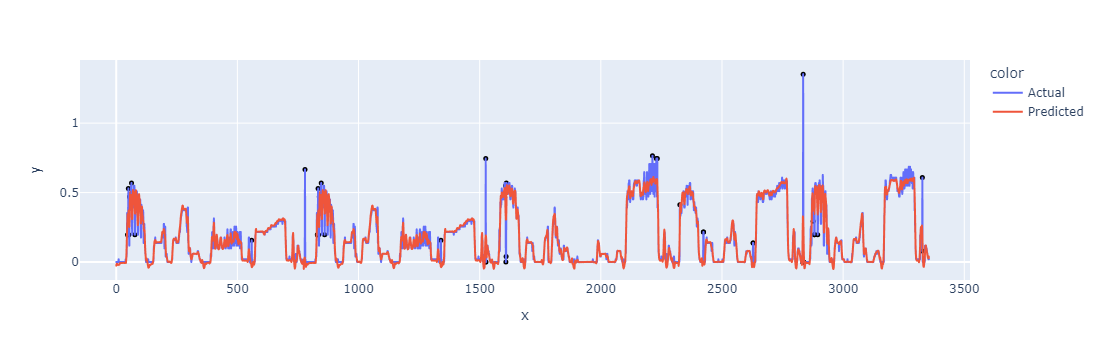

In [ ]:
display_prediction(df20_trainX, predicted_load_train_20, 4, mean, std, 2)

In [ ]:
df_risk_comparision = dfN10_load[dfN10_load['cr'].isin(['CR-3','CR-15'])]
len(df_risk_comparision)

1187

In [ ]:
df_risk_comparision = df_risk_comparision.drop_duplicates(subset=['timestamp'], keep ='first')
df_risk_comparision.reset_index(drop=True)
len(df_risk_comparision)

1187

In [ ]:
df_risk_base = df_risk_comparision[df_risk_comparision['cr'].isin(['CR-3'])]
df_risk_test = df_risk_comparision[df_risk_comparision['cr'].isin(['CR-15'])]

In [ ]:
df_risk_base = df_risk_base[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]
df_risk_test = df_risk_test[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]


In [ ]:

df_risk_base_scaled = data_scaled.transform(df_risk_base)
df_risk_test_scaled = data_scaled.transform(df_risk_test)

print(df_risk_base_scaled.shape, df_risk_test_scaled.shape)

(664, 6) (523, 6)


In [ ]:
df_risk_base_scaled.max()

1.0

In [ ]:
df_risk_test_scaled.max()

0.9929808530963159

In [ ]:
df_risk_base_scaled_x, df_risk_base_scaled_y = to_sequences(df_risk_base_scaled, 10)
print(df_risk_base_scaled_x.shape, df_risk_base_scaled_y.shape)

(654, 10, 6) (654, 6)


In [ ]:
df_risk_test_scaled_x, df_risk_test_scaled_y = to_sequences(df_risk_test_scaled, 10)
print(df_risk_test_scaled_x.shape, df_risk_test_scaled_y.shape)

(513, 10, 6) (513, 6)


In [140]:
def mark_anomalies_current_method_on_production(x, y, t):
    anomalies = []
    count = 0
    for i in range(len(y)):
        if i >= len(x):
            anomalies.append(False)
            # break
        elif y[i, t, 0] > 1.25 * x[i, t, 0] or y[i, t, 0] < 0.75 * x[i, t, 0]:
            anomalies.append(True)
            count += 1
        else:
            anomalies.append(False)
    return np.array(anomalies)


In [141]:
anomalies = mark_anomalies_current_method_on_production(df_risk_base_scaled_x, df_risk_test_scaled_x, 4)
len(anomalies)

NameError: name 'df_risk_base_scaled_x' is not defined

In [142]:
def display_seq(x, y, t):

    anomalies = mark_anomalies_current_method_on_production(x, y, t)
    df1 = pd.DataFrame({'x': range(len(x)), 'y': x[:, t, 0], 'color': 'Baseline', 'anomaly': False})
    df2 = pd.DataFrame({'x': range(len(y)), 'y': y[:, t, 0], 'color': 'New CR', 'anomaly': anomalies})

    df = pd.concat([df1, df2])
    fig = px.line(df, x='x', y='y', color='color')

    df_anomaly = df[df['anomaly']==True]
    print("Number of anomalies: ", len(df_anomaly))
    scatter_data = px.scatter(df_anomaly, x='x', y='y', color_discrete_sequence=['black']).data[0]
    scatter_data.update(marker=dict(size=5))
    fig.add_trace(scatter_data)

    fig.show()


In [143]:
def display_prediction_new(df10_trainX, predicted_load_train, baseline, t, mean, std, relax):
    
    anomaly=mark_anomaly(df10_trainX, predicted_load_train, t, mean, std, relax)
    # print()
    # Create DataFrames for actual and predicted values
    # print(anomaly)
    df1 = pd.DataFrame({'x': range(len(df10_trainX)), 'y': df10_trainX[:, t, 0], 'color': 'Actual Load', 'anomaly': anomaly})
    df2 = pd.DataFrame({'x': range(len(predicted_load_train)), 'y': predicted_load_train[:, t, 0], 'color': 'Predicted Baseline', 'anomaly': False})
    df3 = pd.DataFrame({'x': range(len(baseline)), 'y': baseline[:, t, 0], 'color': 'Old Baseline', 'anomaly':False})
    
    # Concatenate the DataFrames
    df = pd.concat([df1, df2, df3])
    # print(df)
    # Plot both actual and predicted values
    fig = px.line(df, x='x', y='y', color='color')

    df_anomaly = df[df['anomaly']==True]
    print("Number of anomalies: ", len(df_anomaly))
    scatter_data = px.scatter(df_anomaly, x='x', y='y', color_discrete_sequence=['black']).data[0]
    scatter_data.update(marker=dict(size=5))
    fig.add_trace(scatter_data)

    fig.show()


In [144]:
def mark_risk_new(current_load, new_base, t, mean, std, relax):

    tool_disengagement_counter = 0
    tool_overload_counter = 0
    roc_counter = 0

    num_tool_disengagement = 0
    num_tool_overload = 0
    num_roc = 0

    prev_base_load = None
    prev_current_load = None
    for index, (x, y) in enumerate(zip(current_load[:,t,0], new_base[:, t, 0])):
        error = x - y
        # print(error)
        if error > mean + relax*std:
            tool_overload_counter += 1
            if tool_overload_counter > 5:
                # print("new num_tool_overload", index)
                num_tool_overload += 1
                tool_overload_counter = 0
        else:
            tool_overload_counter = 0

        if error < mean - relax*std:
            tool_disengagement_counter += 1
            if tool_disengagement_counter > 5:
                num_tool_disengagement += 1
                tool_disengagement_counter = 0
        else:
            tool_disengagement_counter = 0
        
        if prev_base_load!= None and prev_current_load != None:
            dy = abs(prev_base_load - x)
            dx = abs(prev_current_load - y)
            if dx == 0:
                continue
            slope = dy/dx
            if slope > 2:
                num_roc += 1
                if num_roc >=2 :
                    num_roc = 0
            else:
                num_roc = 0
                
            
        prev_base_load = x
        prev_current_load = y

    data = [
           {'risk_type': 'tool_disengagement', 'risk_count': num_tool_disengagement, 'method': 'New Method'},
           {'risk_type': 'tool_overload', 'risk_count': num_tool_overload, 'method': 'New Method'},
           {'risk_type': 'roc', 'risk_count': num_roc, 'method': 'New Method'},
    ]
    df = pd.DataFrame.from_dict(data)
    return df

In [145]:
def mark_risk_old(current_load, new_base, t):

    tool_disengagement_counter = 0
    tool_overload_counter = 0
    roc_counter = 0

    num_tool_disengagement = 0
    num_tool_overload = 0
    num_roc = 0

    prev_base_load = None
    prev_current_load = None

    for index, (x, y) in enumerate(zip(current_load[:,t,0], new_base[:, t, 0])):
        # error = x - y
        # print(error)
        if x > 1.25*y:
            tool_overload_counter += 1
            if tool_overload_counter > 5:
                # print("num_tool_overload", index, x, y, 1.25*x, .75*x)
                num_tool_overload += 1
                tool_overload_counter = 0
        else:
            tool_overload_counter = 0

        if x < .75*y:
            tool_disengagement_counter += 1
            if tool_disengagement_counter > 5:
                # print("num_tool_diseng", index, x, y, 1.25*x, .75*x)
                num_tool_disengagement += 1
                tool_disengagement_counter = 0
        else:
            tool_disengagement_counter = 0
        
        if prev_base_load!= None and prev_current_load != None:
            dy = abs(prev_base_load - x)
            dx = abs(prev_current_load - y)
            if dx == 0:
                continue
            slope = dy/dx
            
            # print(slope, dy, dx)
            if slope > 2:
                num_roc += 1
                if num_roc >=2 :
                    num_roc = 0
            else:
                num_roc = 0
                
            
        prev_base_load = x
        prev_current_load = y

    # risk = {
    #     'tool_disengagement' : num_tool_disengagement,
    #     'tool_overload': num_tool_overload,
    #     'roc': num_roc,
    #     'method': 'Old Method'
    # }
    # pd.DataFrame.from_dict(risk)
    # return risk
    data = [
           {'risk_type': 'tool_disengagement', 'risk_count': num_tool_disengagement, 'method': 'Old Method'},
           {'risk_type': 'tool_overload', 'risk_count': num_tool_overload, 'method': 'Old Method'},
           {'risk_type': 'roc', 'risk_count': num_roc, 'method': 'Old Method'},
    ]
    df = pd.DataFrame.from_dict(data)
    return df

In [ ]:
# number of risks from current methodology on production

In [146]:
display_seq(df_risk_base_scaled_x, df_risk_test_scaled_x, 4)

NameError: name 'df_risk_base_scaled_x' is not defined

In [ ]:
# risks from new methodology, here red (predicted) line is the basline generated by the model while green line is fixed baseline from current method

In [147]:
df_risk_test_scaled_x_predicted = model.predict(df_risk_test_scaled_x)
display_prediction_new(df_risk_test_scaled_x, df_risk_test_scaled_x_predicted, df_risk_base_scaled_x, 4, mean, std, 2)

NameError: name 'df_risk_test_scaled_x' is not defined

In [ ]:
def classify_anomaly(current_load, new_base, old_base, t, mean, std, relax):
    new_anomalies = mark_risk_new(current_load, new_base, t, mean, std, relax)
    # print(new_anomalies)
    old_anomalies = mark_risk_old(current_load, old_base, t)
    concatenated_df = pd.concat([old_anomalies, new_anomalies])
    
    # Reset the index of the concatenated DataFrame
    concatenated_df.reset_index(drop=True, inplace=True)
    fig = px.bar(concatenated_df, x="method", y="risk_count", color="risk_type", title="risks")
    fig.show()
    
    # print(new_anomalies)
    # print(old_anomalies)

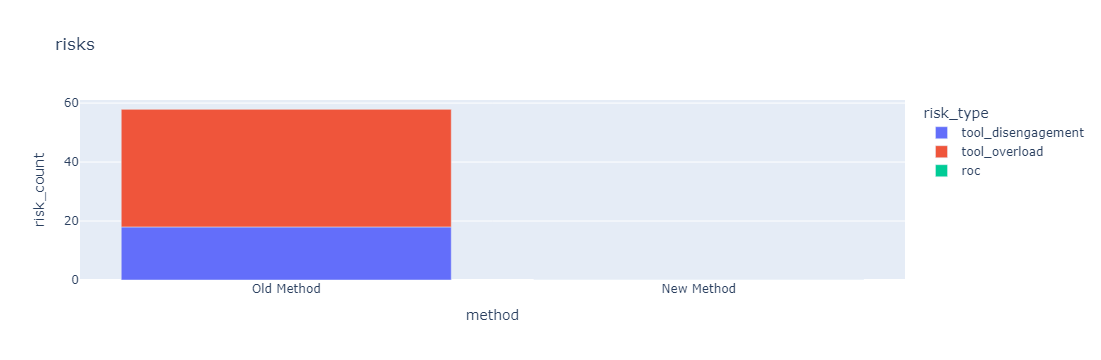

In [ ]:
classify_anomaly(df_risk_test_scaled_x, df_risk_test_scaled_x_predicted, df_risk_base_scaled_x, 4, mean, std, 2)

Number of anomalies:  167


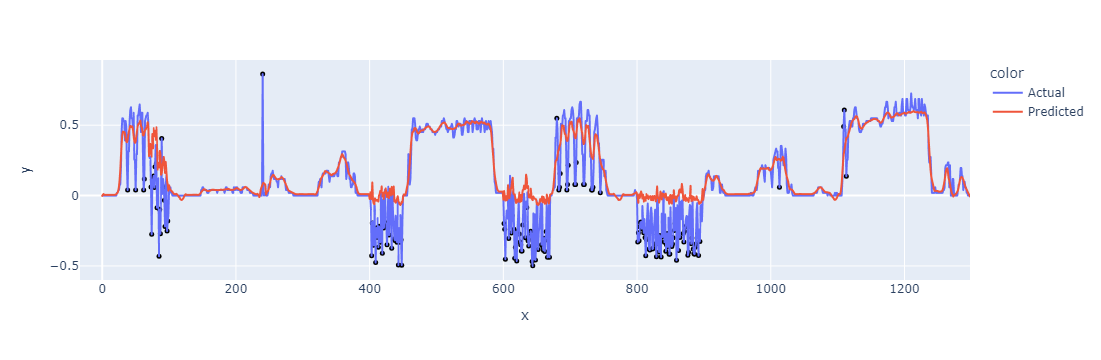

In [ ]:
display_prediction(noise_data, predicted_load_test_noise, 4,  mean, std, 2)

In [148]:
def get_cr_run_current_load_and_baseline(base_cr, current_cr, dfN10_load_filtered_cr):
    basecr = dfN10_load_filtered_cr[dfN10_load_filtered_cr['cr_numeric'].isin([base_cr])]
    current_cr = dfN10_load_filtered_cr[dfN10_load_filtered_cr['cr_numeric'].isin([current_cr])]

    basecr = basecr[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]
    current_cr = current_cr[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]
    
    scaler = MinMaxScaler()
    data_scaled = scaler.fit(basecr)
    # Scaling dataset according to weights of train data
    basecr_scaled = data_scaled.transform(basecr)
    current_cr_scaled = data_scaled.transform(current_cr)
    return basecr_scaled, current_cr_scaled

In [149]:
def plot_new_and_old_risks(base_cr, current_cr, dfN10_load_filtered_cr, relax):
    base, curr = get_cr_run_current_load_and_baseline(base_cr, current_cr, dfN10_load_filtered_cr)
    base_x, base_y = to_sequences(base, 10)
    curr_x, curr_y = to_sequences(curr, 10)
    predicted = model.predict(curr_x)

    display_seq(base_x, curr_x, 4)
    display_prediction_new(curr_x, predicted, base_x, 4, mean, std, relax)
    classify_anomaly(curr_x, predicted, base_x, 4, mean, std, relax)

In [150]:
plot_new_and_old_risks(3, 12, dfN10_load, 2)

KeyError: 'cr_numeric'

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Number of anomalies:  476


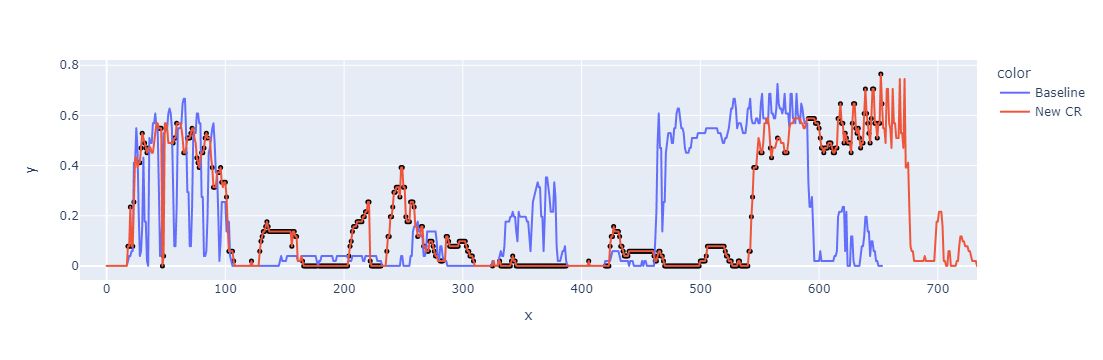

Number of anomalies:  3


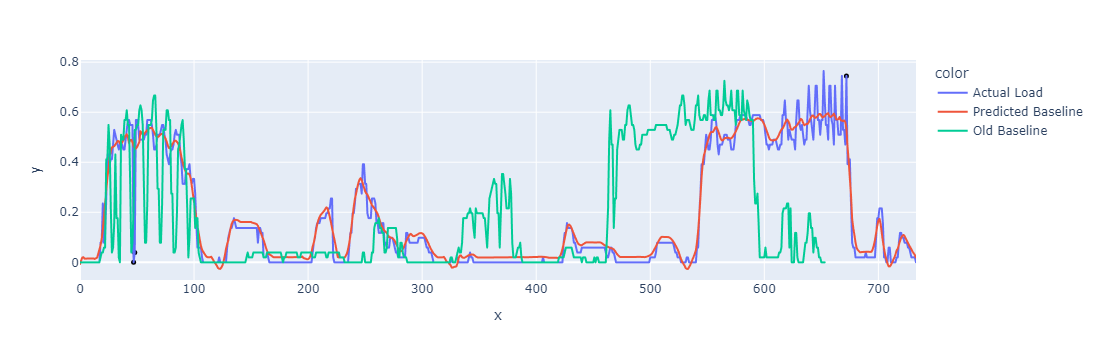

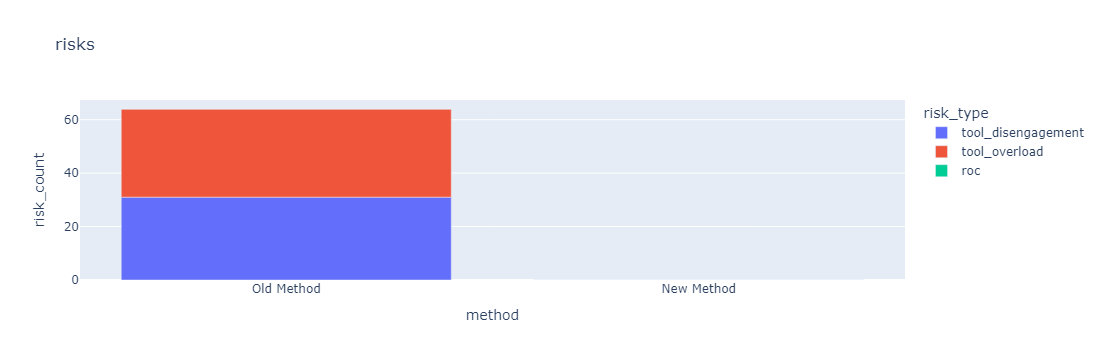

In [ ]:
plot_new_and_old_risks(3, 13, dfN10_load, 2)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Number of anomalies:  445


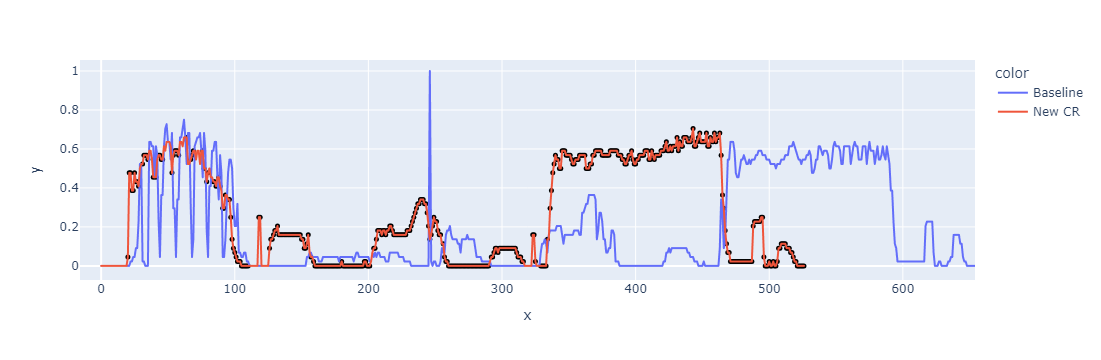

Number of anomalies:  3


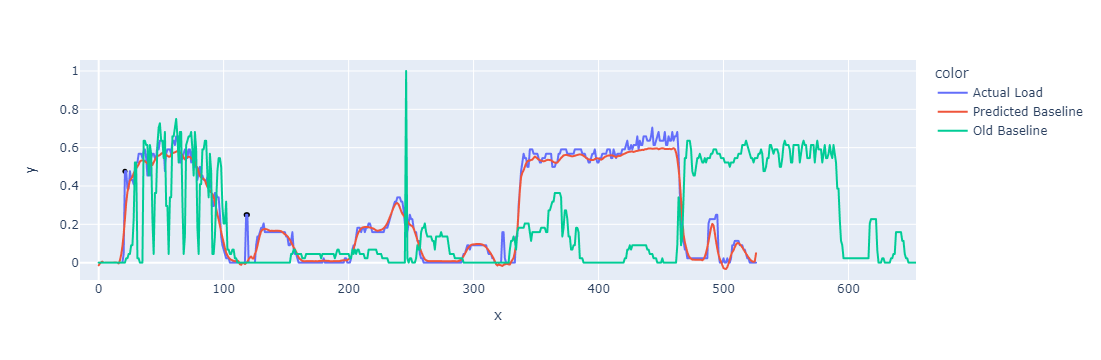

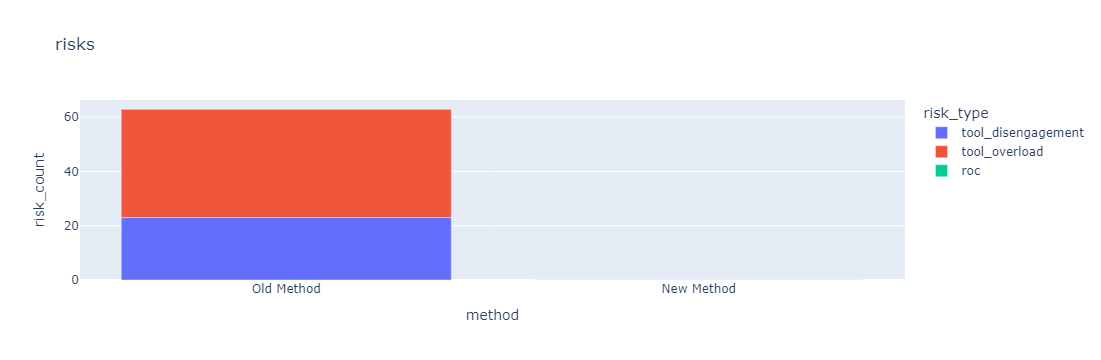

In [ ]:
plot_new_and_old_risks(2, 14, dfN10_load, 2)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Number of anomalies:  431


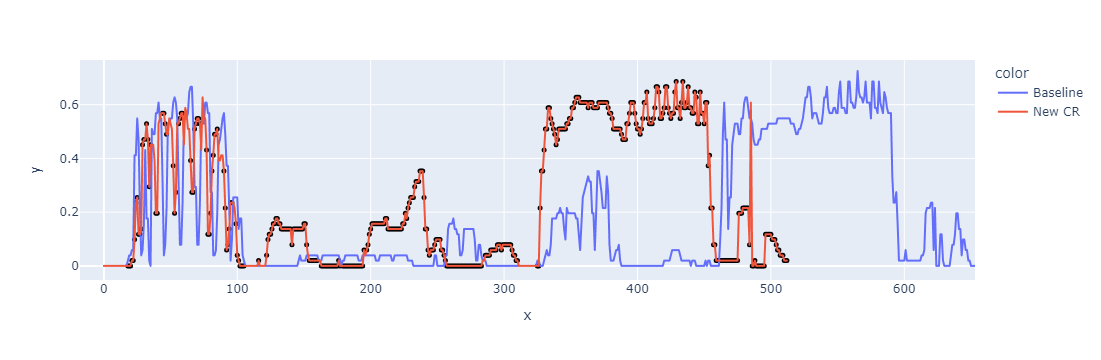

Number of anomalies:  10


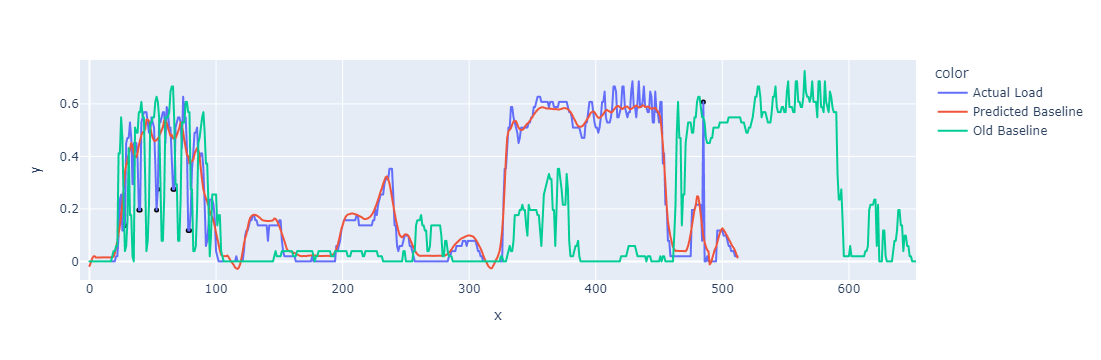

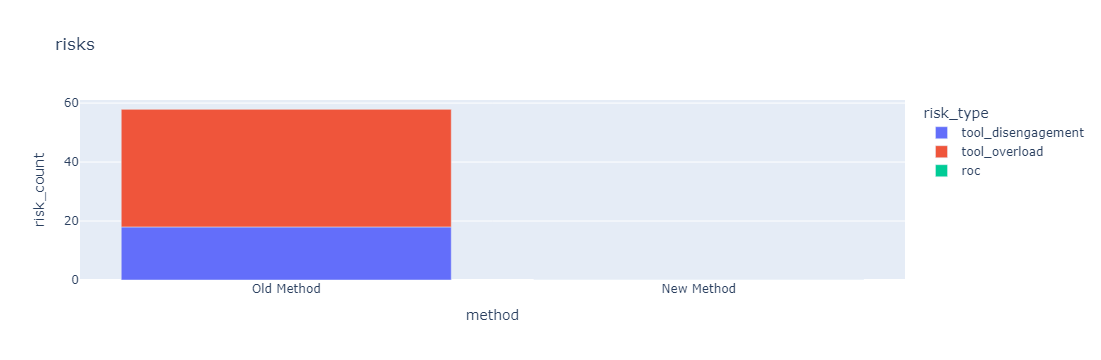

In [ ]:
plot_new_and_old_risks(3, 15, dfN10_load, 2)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Number of anomalies:  433


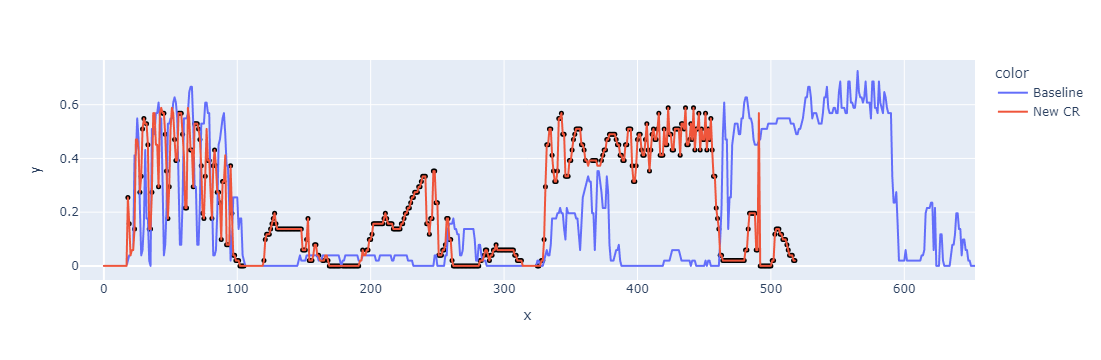

Number of anomalies:  11


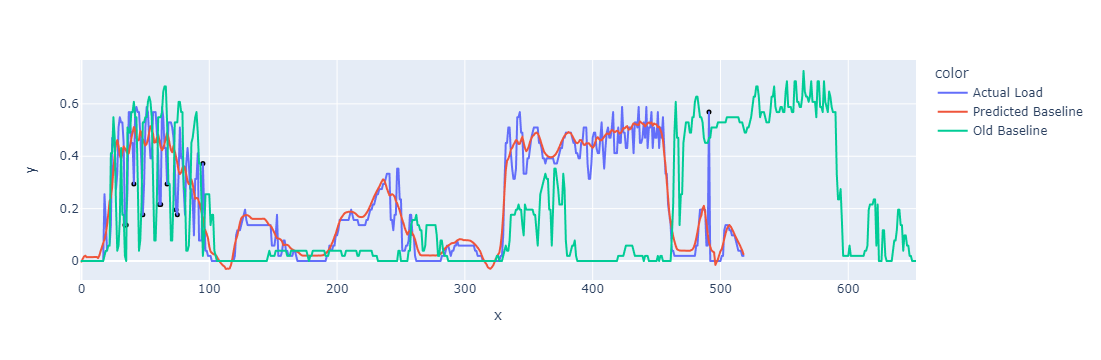

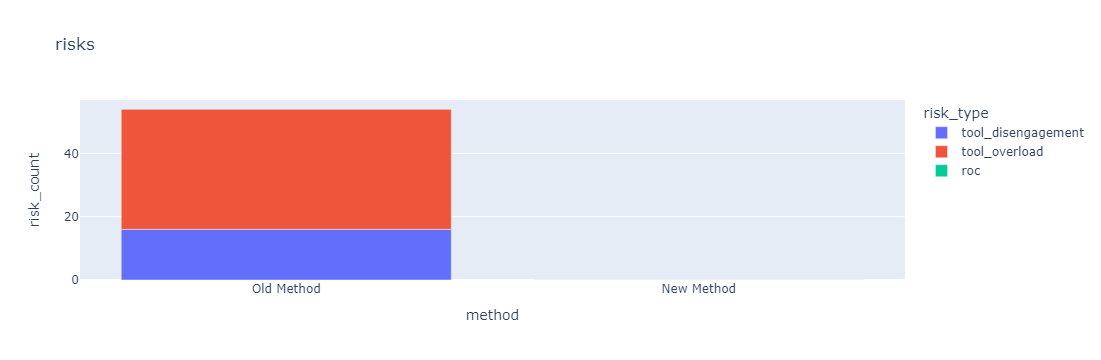

In [ ]:
plot_new_and_old_risks(3, 16, dfN10_load, 2)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Number of anomalies:  433


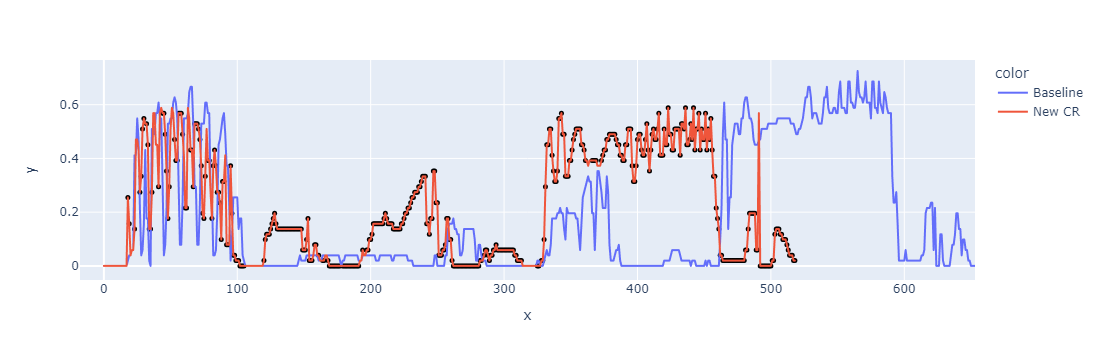

Number of anomalies:  11


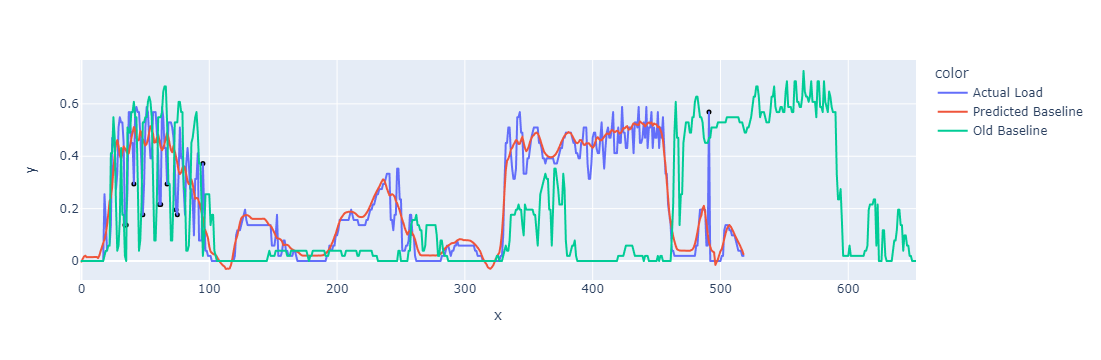

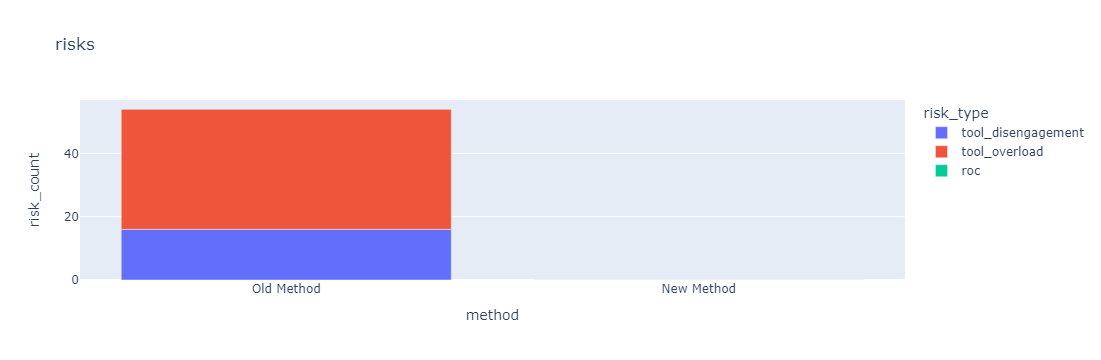

In [ ]:
plot_new_and_old_risks(3, 16, dfN10_load, 2)

In [151]:
#dilation
def plot_new_and_old_risks_for_dilation(base_cr, current_cr, dfN10_load_filtered_cr, prob, dup_count, relax):
    base, curr = get_cr_run_current_load_and_baseline(base_cr, current_cr, dfN10_load_filtered_cr)
    curr = duplicate_rows_with_probability(curr, prob, dup_count)
    base_x, base_y = to_sequences(base, 10)
    curr_x, curr_y = to_sequences(curr, 10)
    predicted = model.predict(curr_x)

    display_seq(base_x, curr_x, 4)
    display_prediction_new(curr_x, predicted, base_x, 4, mean, std, relax)
    classify_anomaly(curr_x, predicted, base_x, 4, mean, std, relax)

In [152]:
plot_new_and_old_risks_for_dilation(3, 12, dfN10_load, 0.1, 5, 2)

KeyError: 'cr_numeric'

In [156]:
def get_data(machines, programs, dates):
    # machines= ['SL40309_015']
    # programs= ['O0005(5303-005-C)']
    # nsequences= ['N1']
    # dates= ['CR1_to_CR4', 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']
    base_name = 'data'
    paths = []
    
    # data_SL40309_015_O0005(5303-005-C)_CR12_to_CR16
    
    for machine in machines:
        for program in programs:
                for date in dates:
                    path = f'{base_name}_{machine}_{program}_{date}.csv'
                    paths.append(path)
    print(paths)
    
    dfs = []
    
    for path in paths:
        data = pd.read_csv(f'../data/{path}')
        dfs.append(data)
        # print(len(data))
        
    data = pd.concat(dfs, ignore_index=True)
    
    data = data.pivot(index=['custom_id', 'timestamp', 'status', 'cr'], columns=['name', 'workstationcomponent'], values='value')
    data = data.reset_index()
    data.columns = [f'{col}_{comp}' if comp != '' else col for col, comp in data.columns]

    split_columns = data['status'].str.split('/', expand=True)
    data[['program_name', 'nsequence', 'execution']] = split_columns[[0,1,2]]
    
    data['load_Rotary_C5'] = data['load_Rotary_C5'].astype(float)
    data['position_Linear_Z'] = data['position_Linear_Z'].astype(float)
    data['position_Linear_X'] = data['position_Linear_X'].astype(float)
    data['spindlespeed_actual_Rotary_C5'] = data['spindlespeed_actual_Rotary_C5'].astype(float)
    data['pathfeedrate_Path_Path_1'] = data['pathfeedrate_Path_Path_1'].astype(float)
    
    data = data.ffill()
    return data

In [ ]:
# machines_diff = ['NL300005_007']
# programs_diff = ['O4073(3980-050-C)']
# dates_diff = ['CR1_to_CR4'] #, 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']
# # data_NL250007_013_O4125(5211-020-D)_N1_cr_1_to_5
# # data_NL300005_007_O4073(3980-050-C)_CR1_to_CR4

# data = get_data(machines_diff, programs_diff, dates_diff)

In [157]:
# raw_data_SL40309_015_O0020(5304-020-F)_N10_2024-03-19

machines_diff = ['SL40309_015']
programs_diff = ['O0020(5304-020-F)']
dates_diff = ['N10_2024-03-19'] #, 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']
# data_NL250007_013_O4125(5211-020-D)_N1_cr_1_to_5
# data_NL300005_007_O4073(3980-050-C)_CR1_to_CR4

data = get_data(machines_diff, programs_diff, dates_diff)

['data_SL40309_015_O0020(5304-020-F)_N10_2024-03-19.csv']


In [158]:
len(data)

25024

In [159]:
def check_model_on_different_program(machines, programs, dates):
    data = get_data(machines_diff, programs_diff, dates_diff)
    data = data[(data['execution'] == 'ACTIVE') & 
            (data['spindlespeed_actual_Rotary_C5'] != 0) & 
            (data['pathfeedrate_Path_Path_1'] != 0) & 
            (data['load_Rotary_C5'] > 0) & 
            (data['pathfeedrate_Path_Path_1'] <= 1000)]
    
    # data_c = data[data['program_name'].isin(['O4125(5211-020-D)'])]
    # dfN10 = data_c[data_c['nsequence'].isin(['N1'])]
    data.dropna(subset=['load_Rotary_C5'],inplace=True)
    
    df_diff = data[['timestamp', 'load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution', 'program_name', 'nsequence', 'cr']]
    df_diff = df_diff.drop_duplicates(subset=['timestamp'], keep ='first')
    df_diff.reset_index(drop=True)

    df_diff['index'] = df_diff.groupby(['cr']).cumcount()
    
    fig = px.line(df_diff, x="index", y="load_Rotary_C5", color='cr')
    fig.update_layout(title_text="Load Vs Index")
    fig.show()

    df_diff['execution'] = LE.fit_transform(df_diff['execution'])
    df_diff.fillna(0, inplace=True)

    df_diff[['load_Rotary_C5']]= scaler1.fit_transform(df_diff[['load_Rotary_C5']])

    df_diff = df_diff[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]

    # scalar = MinMaxScaler()
    # data_scaled = scaler.fit(df_diff)
    # df_diff_scaled = data_scaled.transform(df_diff)
    df_diff_scaled = data_scaled.transform(df_diff)
    print(f"Max Before {df_diff.max()}")
    print(f"Max After {df_diff_scaled.max()}")
    # df_diff_scaled[-3]
    df10_trainX_diff, df10_trainY_diff = to_sequences(df_diff_scaled, 10)
    predicted_diff = model.predict(df10_trainX_diff)
    # print(predicted_diff[0:10])
    display_prediction(df10_trainX_diff, predicted_diff, 4, mean, std, 2)
    


In [160]:
machines_diff = ['SL40309_015']
programs_diff = ['O0020(5304-020-F)']
dates_diff = ['N10_2024-03-19'] #, 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']
check_model_on_different_program(machines_diff, programs_diff, dates_diff)

['data_SL40309_015_O0020(5304-020-F)_N10_2024-03-19.csv']


Max Before load_Rotary_C5                     1.0000
position_Linear_X                 24.8753
position_Linear_Z                 17.7050
spindlespeed_actual_Rotary_C5     57.0000
pathfeedrate_Path_Path_1         259.5800
execution                          0.0000
dtype: float64
Max After 1.2516257125810348
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Number of anomalies:  0


In [161]:
machines_diff = ['NL250007_013']
programs_diff = ['O4125(5211-020-D)']
# data_SL40309_015_O0005(5303-005-C)_CR1_to_CR4
# data_NL250007_013_O4125(5211-020-D)_N1_cr_1_to_5
dates_diff = ['N1_cr_1_to_5']
check_model_on_different_program(machines_diff, programs_diff, dates_diff)

['data_NL250007_013_O4125(5211-020-D)_N1_cr_1_to_5.csv']


Max Before load_Rotary_C5                     1.00000
position_Linear_X                453.49922
position_Linear_Z                320.95440
spindlespeed_actual_Rotary_C5     73.00000
pathfeedrate_Path_Path_1         629.00000
execution                          0.00000
dtype: float64
Max After 22.741812274694034
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Number of anomalies:  3412


In [168]:
machines_diff = ['SL40309_015']
programs_diff = ['O0020(5304-020-F)']
dates_diff = ['N10_2024-03-19'] #, 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']

# machines_diff = ['SL40309_015']
# programs_diff = ['O0005(5303-005-C)']
# # data_SL40309_015_O0005(5303-005-C)_CR1_to_CR4
# dates_diff = ['CR1_to_CR4', 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']

data = get_data(machines_diff, programs_diff, dates_diff)
data = data[(data['execution'] == 'ACTIVE') & 
        (data['spindlespeed_actual_Rotary_C5'] != 0) & 
        (data['pathfeedrate_Path_Path_1'] != 0) & 
        (data['load_Rotary_C5'] > 0) & 
        (data['pathfeedrate_Path_Path_1'] <= 1000)]

# data_c = data[data['program_name'].isin(['O4125(5211-020-D)'])]
# dfN10 = data_c[data_c['nsequence'].isin(['N1'])]
data.dropna(subset=['load_Rotary_C5'],inplace=True)

df_diff = data[['timestamp', 'load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution', 'program_name', 'nsequence', 'cr']]
df_diff = df_diff.drop_duplicates(subset=['timestamp'], keep ='first')
df_diff.reset_index(drop=True)

df_diff['index'] = df_diff.groupby(['cr']).cumcount()

df_diff['execution'] = LE.fit_transform(df_diff['execution'])
df_diff.fillna(0, inplace=True)
# scaler1 = MinMaxScaler()

# df_diff[['load_Rotary_C5']]= scaler2.fit_transform(df_diff[['load_Rotary_C5']])
df_diff = df_diff[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]

# scalar = MinMaxScaler()
# data_scaled = scaler.fit(df_diff)
df_diff_scaled = scaler2.transform(df_diff)


['data_SL40309_015_O0020(5304-020-F)_N10_2024-03-19.csv']


In [169]:
df_diff_scaled.max()

np.float64(1.2516257125810348)

In [170]:
df_diff_scaled

array([[ 2.74509804e-01,  1.02633730e+00,  1.07283146e+00,
         7.65550239e-02,  1.06574739e+00,  0.00000000e+00],
       [ 3.92156863e-02,  7.60693103e-01,  8.31153613e-01,
         7.65550239e-02,  1.06574739e+00,  0.00000000e+00],
       [ 3.92156863e-02,  7.60693103e-01,  5.46059041e-01,
         7.89473684e-02,  1.06566433e+00,  0.00000000e+00],
       ...,
       [ 3.92156863e-02,  7.22984593e-01,  2.56378325e-01,
         5.98086124e-02, -8.30668273e-05,  0.00000000e+00],
       [ 1.96078431e-02,  7.22508285e-01,  3.01931879e-01,
         5.02392344e-02,  7.80329775e-01,  0.00000000e+00],
       [ 1.96078431e-02,  7.64684058e-01,  5.81236329e-01,
         4.78468900e-02,  9.83428168e-01,  0.00000000e+00]],
      shape=(3482, 6))

In [171]:
df_diff

,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1,execution
18,15.0,20.3819,17.7050,45.0,256.83,0
23,3.0,15.0836,12.4458,45.0,256.83,0
29,3.0,15.0836,6.2418,46.0,256.81,0
88,3.0,11.4611,2.0000,46.0,236.20,0
93,3.0,11.4611,-0.0620,46.0,236.20,0
...,...,...,...,...,...,...
24773,3.0,14.3431,-0.0620,38.0,0.21,0
24775,3.0,14.3315,-0.0620,38.0,0.21,0
24776,3.0,14.3315,-0.0620,38.0,0.21,0
24987,2.0,14.3220,0.9293,34.0,188.11,0


In [172]:
df_diff.max()

load_Rotary_C5                    43.0000
position_Linear_X                 24.8753
position_Linear_Z                 17.7050
spindlespeed_actual_Rotary_C5     57.0000
pathfeedrate_Path_Path_1         259.5800
execution                          0.0000
dtype: float64

In [173]:
df10_trainX_diff, df10_trainY_diff = to_sequences(df_diff_scaled, 10)
predicted_diff = model.predict(df10_trainX_diff)
display_prediction(df10_trainX_diff, predicted_diff, 4, mean, std, 2)

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Number of anomalies:  13
